# Multimodal Emotion Detection - Fusion of ResNet50 and DistilBERT

## Imports

In [24]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from PIL import Image
from transformers import DistilBertTokenizer, DistilBertModel
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns


## Paths & Device

In [25]:
# Dataset path
ROOT_DIR = r"C:\Users\USER\PycharmProjects\DSGP15_Project\ml-models\dataset\Dataset"

# BERT saved model
BERT_MODEL_DIR = r"/ml-models/mood/notebooks/Pipeline/data/saved_emotion_bert"

# ResNet50 saved model
RESNET_MODEL_PATH = r"/ml-models/mood/notebooks/Pipeline/data/resnet50_emotion_model_cpu_optimized.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


## Load Tokenizer and BERT

In [26]:
tokenizer = DistilBertTokenizer.from_pretrained(BERT_MODEL_DIR)
bert = DistilBertModel.from_pretrained(BERT_MODEL_DIR)
bert.eval()
bert = bert.to(device)


## Text Feature Extraction Function

In [27]:
def extract_text_features(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=64
    )
    inputs = {k:v.to(device) for k,v in inputs.items()}

    with torch.no_grad():
        outputs = bert(**inputs)

    return outputs.last_hidden_state[:, 0, :]  # CLS token


## Image Transformations

In [28]:
IMG_SIZE = 224
BATCH_SIZE = 16

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])


## Dataset & DataLoader

In [29]:
train_dir = os.path.join(ROOT_DIR, "Images", "Emotion", "train")
test_dir = os.path.join(ROOT_DIR, "Images", "Emotion", "test")

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Classes:", train_dataset.classes)


Classes: ['Happiness', 'Sadness']


## Load ResNet50

In [30]:
# Load base ResNet50
resnet = models.resnet50(pretrained=False)  # don't load ImageNet weights
resnet.fc = nn.Linear(resnet.fc.in_features, 2)  # match your saved classifier output

# Load the saved trained weights
resnet.load_state_dict(torch.load(RESNET_MODEL_PATH, map_location=device))

# Remove classifier for feature extraction (for fusion)
resnet.fc = nn.Identity()

resnet = resnet.to(device)
resnet.eval()
print("ResNet50 loaded successfully")


C:\Users\USER\PycharmProjects\DSGP15_Project\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet50 loaded successfully


## Fusion Model Definition

In [31]:
class MultimodalEmotionClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(2048 + 768, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 2)  # happy / sad
        )

    def forward(self, image_feat, text_feat):
        fused = torch.cat((image_feat, text_feat), dim=1)
        return self.fc(fused)

fusion_model = MultimodalEmotionClassifier().to(device)


## Loss and Optimizer

In [32]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(fusion_model.parameters(), lr=2e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)


## Training Loop

In [33]:
EPOCHS = 5
fusion_model.train()

for epoch in range(EPOCHS):
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Extract image features
        with torch.no_grad():
            img_feat = resnet(images)

        # Dummy text feature (replace with real captions if available)
        texts = ["The child looks happy"] * images.size(0)
        txt_feat = torch.cat([extract_text_features(t) for t in texts], dim=0)

        optimizer.zero_grad()
        outputs = fusion_model(img_feat, txt_feat)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    scheduler.step()
    print(f"Epoch [{epoch+1}/{EPOCHS}] - Loss: {running_loss/len(train_loader):.4f}")


Epoch [1/5] - Loss: 0.0209
Epoch [2/5] - Loss: 0.0160
Epoch [3/5] - Loss: 0.0148
Epoch [4/5] - Loss: 0.0114
Epoch [5/5] - Loss: 0.0082


## Evaluation Function

In [34]:
def evaluate_model(model, loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            img_feat = resnet(images)
            texts = ["The child looks happy"] * images.size(0)
            txt_feat = torch.cat([extract_text_features(t) for t in texts], dim=0)

            outputs = model(img_feat, txt_feat)
            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    return np.array(y_true), np.array(y_pred)


## Evaluate Fusion Model

Test Accuracy: 0.73


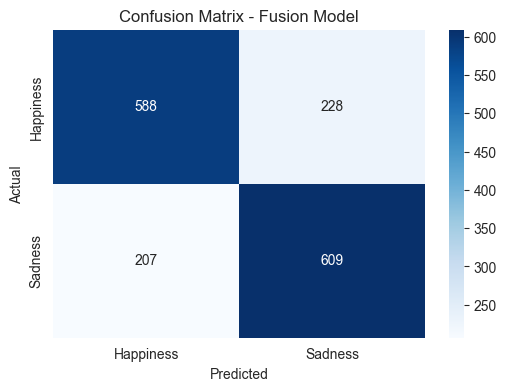

Classification Report:
               precision    recall  f1-score   support

   Happiness       0.74      0.72      0.73       816
     Sadness       0.73      0.75      0.74       816

    accuracy                           0.73      1632
   macro avg       0.73      0.73      0.73      1632
weighted avg       0.73      0.73      0.73      1632



In [35]:
y_true, y_pred = evaluate_model(fusion_model, test_loader)

accuracy = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {accuracy:.2f}")

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=train_dataset.classes, yticklabels=train_dataset.classes, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Fusion Model")
plt.show()

print("Classification Report:\n", classification_report(y_true, y_pred, target_names=train_dataset.classes))


## Save Fusion Model

In [36]:
FUSION_MODEL_PATH = r"/ml-models/mood/notebooks/Pipeline/data/fusion_model.pth"
os.makedirs(os.path.dirname(FUSION_MODEL_PATH), exist_ok=True)
torch.save(fusion_model.state_dict(), FUSION_MODEL_PATH)
print("Fusion model saved successfully")


Fusion model saved successfully


## Single Prediction Inference

In [39]:
def predict_emotion(image_path, text, image_transform=val_test_transform):

    fusion_model.eval()
    resnet.eval()
    bert.eval()

    # Load and transform image
    image = Image.open(image_path).convert("RGB")
    image = image_transform(image).unsqueeze(0).to(device)

    # Extract image features
    with torch.no_grad():
        img_feat = resnet(image)

    # Extract text features
    txt_feat = extract_text_features(text)

    # Fusion model prediction
    with torch.no_grad():
        output = fusion_model(img_feat, txt_feat)
        pred_idx = torch.argmax(output, dim=1).item()

    # Map class index to label
    label_map = {0: "happy", 1: "sad"}
    return label_map[pred_idx]


# Example usage
example_image = r"C:\Users\USER\PycharmProjects\DSGP15_Project\ml-models\dataset\Dataset\Images\Emotion\test\example1.jpg"
example_text = "The child looks happy"
prediction = predict_emotion(example_image, example_text)
print("Predicted Emotion:", prediction)


Predicted Emotion: happy
